In [1]:
from lib.graph_plot import plot_pairs
from lib.normalizer import min_max_only_ppi
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import pickle

In [2]:
TARGET = 'CRS'

# MinMax Normalization
This is done so that the data is between 0 and 1 and can be loaded in to the model

In [3]:
def preprocess_data(df, target, normalize=True):
    target_df = df[target]
    # ppi columns are the columns with '_' in the name
    ppi_columns = [col for col in df.columns if '_' in col]
    ppi_df = df[ppi_columns]

    if normalize:
        ppi_df = min_max_only_ppi(ppi_df)

    return ppi_df, target_df

In [4]:
# do cross validation with random forest
# load the prenormalized data
df = pd.read_csv('../Step1Normalization/output/normalized_output.csv', index_col=0)

df

,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,cd4v8,protein conc,CRS,stim type,pair num,control
CAR_19_447,-4.749707,30.321742,8.480109,1.118115,3.602567,8.326768,-20.335256,-1.413745,8.022215,4.032078,...,2.530556,0.566396,-1.439545,-11.550113,4.0,1.740,1.0,19,0,0
CAR_19_452,4.749707,-30.321742,-8.480109,-1.118115,-3.602567,-8.326768,20.335256,1.413745,-8.022215,-4.032078,...,-2.530556,-0.566396,1.439545,11.550113,4.0,1.680,0.0,19,0,0
CAR_19_474,2.713717,1.923312,1.462812,-0.944203,2.485649,0.757548,1.487158,0.114801,4.464405,-4.948528,...,2.838855,1.023444,-3.355369,-7.421004,4.0,3.391,1.0,19,1,0
CAR_19_411,-2.713717,-1.923312,-1.462812,0.944203,-2.485649,-0.757548,-1.487158,-0.114801,-4.464405,4.948528,...,-2.838855,-1.023444,3.355369,7.421004,4.0,3.600,0.0,19,1,0
CAR_N3_874_1,-6.269194,0.495713,-1.323618,2.032515,-2.338702,8.274693,-3.130670,3.209151,-1.243606,1.690520,...,3.770183,-1.602564,2.748826,71.949758,8.0,3.002,1.0,N3,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OR_US_3,0.436673,5.249772,-0.390407,-4.586675,1.569816,0.234893,-1.281849,-2.567804,-12.619974,26.527076,...,-0.386387,1.481516,1.536098,68.829391,4.0,1.900,0.0,NaN,U3,0
CRS_US_4,0.522653,-1.434462,-0.961085,-0.277137,-0.639022,-3.094881,1.497354,1.866592,1.050699,-22.361010,...,-1.485659,-1.607511,2.560410,104.326842,4.0,2.000,1.0,NaN,U4,0
OR_US_4,-0.522653,1.434462,0.961085,0.277137,0.639022,3.094881,-1.497354,-1.866592,-1.050699,22.361010,...,1.485659,1.607511,-2.560410,-104.326842,4.0,2.000,0.0,NaN,U4,0
CRS_US_5,3.020618,3.545894,5.030628,-2.008158,3.272755,-1.029170,-3.196146,-0.156811,7.575342,39.978904,...,1.553306,-0.401679,1.034358,-16.634428,4.0,2.000,1.0,NaN,U5,0


In [5]:
# split the data into two control and treatment
control_df = df[df['control'] == 1]
treatment_df = df[df['control'] == 0]

# for treatment the CRS is the "sample row"
treatment_df = treatment_df[treatment_df['CRS'] == 1]

# for control since both are OR we need to iterate each row and randomly select one
pairs = control_df.groupby('pair num')
# Initialize an empty dataframe to store selected controls
selected_controls = pd.DataFrame()

# Iterate through each pair group
for pair_num, group in pairs:
    # Select one row from the group (taking the first row)
    selected_row = group.iloc[0:1]

    # Append to the selected controls dataframe
    selected_controls = pd.concat([selected_controls, selected_row])

# Combine the selected controls with the treatment data
df = pd.concat([treatment_df, selected_controls])

In [6]:
X, y = preprocess_data(df, TARGET)

# RF Classification

In [7]:
def cross_val_top_features(clf, X, y, cv=5, scoring='f1', top_n=1000):
    """
    Perform cross-validation and extract the top N features from each fold,
    while storing predicted and true outcomes for further evaluation.

    Parameters:
    - clf: Classifier (e.g., RandomForestClassifier).
    - X: Features DataFrame.
    - y: Target Series.
    - cv: Number of cross-validation folds (default: 5).
    - scoring: Scoring metric for cross-validation (default: 'f1').
    - top_n: Number of top features to extract per fold (default: 1000).

    Returns:
    - scores: Cross-validation scores.
    - top_features_df: DataFrame of top features per fold.
    - all_results: Dictionary with keys 'y_pred' and 'y_true', containing predictions and true labels.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=0)
    top_features_per_fold = []
    scores = []
    all_results = {'y_pred': [], 'y_true': []}

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        # Split data
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the classifier
        clf.fit(X_train, y_train)

        # Compute score
        score = clf.score(X_test, y_test)  # Change to custom scoring if needed
        scores.append(score)

        # Store predictions and true values
        y_pred = clf.predict(X_test)
        all_results['y_pred'].append(y_pred)
        all_results['y_true'].append(y_test)

        # Extract feature importances
        feature_importances = (
            pd.DataFrame({
                'Feature': X.columns,
                'Importance': clf.feature_importances_
            })
            .sort_values(by='Importance', ascending=False)
        )

        # Get top N features for this fold
        top_features = feature_importances.head(top_n).copy()
        top_features['Fold'] = fold_idx

        # Also label the position within the rank
        n_features = min(top_n, len(X.columns))
        top_features['Rank'] = range(1, n_features + 1)
        top_features_per_fold.append(top_features)

    # Combine top features into a single DataFrame
    top_features_df = pd.concat(top_features_per_fold, ignore_index=True)

    return scores, top_features_df, all_results

In [8]:
clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=0)

# optimize for F1
rf_scores, rf_ranking, rf_pred = cross_val_top_features(clf, X, y, cv=int(len(X)/2), scoring='f1')

# average the scores and print
print(f"Average F1 Fold Cross Validation: {sum(rf_scores)/len(rf_scores)}")

D:\Python Project\CAR-T Analysis Pipeline\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 12 members, which is less than n_splits=20.
  warnings.warn(


Average F1 Fold Cross Validation: 0.8083333333333333


In [9]:
# Borda Count/Average Rank
rf_rank_avg = (
    rf_ranking
      .groupby('Feature', as_index=False)['Rank']
      .mean()                # average Borda rank (lower == better)
      .sort_values(by='Rank')# sort so best (lowest rank) first
)

print("Top Features (Borda Count)")
display(rf_rank_avg[:20])

Top Features (Borda Count)


,Feature,Rank
29,CD28_FYN,1.00
20,BIRC3_LCK,4.45
111,SLP76_TCRb,4.60
145,TRAF2_LCK,9.45
117,TCRb_CD3z,10.15
109,SLP76_SLP76,12.20
78,NCK_TRAF1,12.70
136,TRAF1_TRAF1,15.30
81,PI3K_CD28,16.65
28,CD28_CD3z,19.30


# CD4 and CD8 Subset

In [10]:
cd4_df = df[df['cd4v8'] == 4]
cd8_df = df[df['cd4v8'] == 8]

cd8_X, cd8_y = preprocess_data(cd8_df, TARGET)
cd4_X, cd4_y = preprocess_data(cd4_df, TARGET)

In [11]:
clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=0)

# optimize for F1
cd8_rf_scores, cd8_rf_ranking, cd8_rf_pred = cross_val_top_features(clf, cd8_X, cd8_y, cv=int(len(cd8_X)/2), scoring='f1')

# average the scores and print
print("CD8:")
print(f"Average F1 In Fold Cross Validation: {sum(cd8_rf_scores)/len(cd8_rf_scores)}")

# Borda Count/Average Rank
cd8_rf_rank_avg = (
    cd8_rf_ranking
      .groupby('Feature', as_index=False)['Rank']
      .mean()                # average Borda rank (lower == better)
      .sort_values(by='Rank')# sort so best (lowest rank) first
)

print("Top Features for CD8 (Borda Count)")
display(cd8_rf_rank_avg[:20])

D:\Python Project\CAR-T Analysis Pipeline\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=11.
  warnings.warn(


CD8:
Average F1 In Fold Cross Validation: 0.7878787878787878
Top Features for CD8 (Borda Count)


,Feature,Rank
29,CD28_FYN,2.363636
167,ZAP70_TAK1,6.272727
168,ZAP70_ZAP70,6.818182
39,FYB_CD28,7.636364
131,TRAF1_LCK,10.454545
148,TRAF2_TAK1,11.272727
104,SLP76_CD3z,12.636364
81,PI3K_CD28,13.636364
92,PKCt_FYN,16.272727
145,TRAF2_LCK,17.636364


In [12]:
clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=0)

# optimize for F1
cd4_rf_scores, cd4_rf_ranking, cd4_rf_pred = cross_val_top_features(clf, cd4_X, cd4_y, cv=int(len(cd4_X)/2), scoring='f1')
# average the scores and print
print("CD4:")
print(f"Average F1 In Fold Cross Validation: {sum(cd4_rf_scores)/len(cd4_rf_scores)}")

# Borda Count/Average Rank
cd4_rf_rank_avg = (
    cd4_rf_ranking
      .groupby('Feature', as_index=False)['Rank']
      .mean()                # average Borda rank (lower == better)
      .sort_values(by='Rank')# sort so best (lowest rank) first
)

print("Top Features for CD8 (Borda Count)")
display(cd4_rf_rank_avg[:20])

D:\Python Project\CAR-T Analysis Pipeline\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=9.
  warnings.warn(


CD4:
Average F1 In Fold Cross Validation: 0.7777777777777778
Top Features for CD8 (Borda Count)


,Feature,Rank
163,VAV1_TRAF1,1.111111
111,SLP76_TCRb,2.666667
117,TCRb_CD3z,6.111111
29,CD28_FYN,6.555556
32,CD28_LCK,9.000000
60,LCK_PKCt,15.111111
36,CD28_TRAF1,15.666667
57,LCK_GRAP2,16.222222
159,VAV1_PKCt,17.333333
100,PKCt_TRAF1,17.777778


# Limiting Features Subset
To test if the features are truly important we will limit the features to the top n and see if the model still performs well.

In [13]:
TOP_FEATURES = 10

In [14]:
# do it for all
filtered_df = df[rf_rank_avg['Feature'][:TOP_FEATURES].values].copy()  # Create explicit copy
# Add the target column using .loc accessor
filtered_df.loc[:, TARGET] = df[TARGET]
# split the data into X and y
X, y = preprocess_data(filtered_df, TARGET)
# optimize for F1
clf = RandomForestClassifier(n_estimators=100, random_state=0)
rf_filtered_scores, rf_filtered_ranking, rf_filtered_pred = cross_val_top_features(clf, X, y,
                                                                                      cv=int(len(X)/2), scoring='f1')
# average the scores and print
print(f"Average F1 In Cross Validation: {sum(rf_filtered_scores)/len(rf_filtered_scores)}")
# Borda Count/Average Rank
rf_filtered_rank_avg = (
    rf_filtered_ranking
      .groupby('Feature', as_index=False)['Rank']
      .mean()                # average Borda rank (lower == better)
      .sort_values(by='Rank')# sort so best (lowest rank) first
)
print(f"Top Features for Full (Truncated to Top {TOP_FEATURES} features) (Borda Count)")
display(rf_filtered_rank_avg[:20])

D:\Python Project\CAR-T Analysis Pipeline\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 12 members, which is less than n_splits=20.
  warnings.warn(


Average F1 In Cross Validation: 0.8833333333333334
Top Features for Full (Truncated to Top 10 features) (Borda Count)


,Feature,Rank
5,SLP76_SLP76,1.80
2,CD28_FYN,1.90
8,TRAF1_TRAF1,2.95
9,TRAF2_LCK,5.45
3,NCK_TRAF1,6.05
1,CD28_CD3z,6.15
4,PI3K_CD28,6.95
7,TCRb_CD3z,7.70
6,SLP76_TCRb,7.80
0,BIRC3_LCK,8.25


In [15]:
# limit the features to the top n
filtered_cd8_df = cd8_df[cd8_rf_rank_avg['Feature'][:TOP_FEATURES].values].copy()  # Create explicit copy
# Add the target column using .loc accessor
filtered_cd8_df.loc[:, TARGET] = cd8_df[TARGET]
# split the data into X and y
cd8_X, cd8_y = preprocess_data(filtered_cd8_df, TARGET)
# optimize for F1
clf = RandomForestClassifier(n_estimators=100, random_state=0)
cd8_rf_filtered_scores, cd8_rf_filtered_ranking, cd8_rf_filtered_pred = cross_val_top_features(clf, cd8_X, cd8_y,
                                                                                                     cv=int(len(cd8_X)/2), scoring='f1')
# average the scores and print
print(f"Average F1 In Cross Validation: {sum(cd8_rf_filtered_scores)/len(cd8_rf_filtered_scores)}")
# Borda Count/Average Rank
cd8_rf_filtered_rank_avg = (
    cd8_rf_filtered_ranking
      .groupby('Feature', as_index=False)['Rank']
      .mean()                # average Borda rank (lower == better)
      .sort_values(by='Rank')# sort so best (lowest rank) first
)
print(f"Top Features for CD8 (Truncated to Top {TOP_FEATURES} features) (Borda Count)")
display(cd8_rf_filtered_rank_avg[:20])

D:\Python Project\CAR-T Analysis Pipeline\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=11.
  warnings.warn(


Average F1 In Cross Validation: 0.7878787878787878
Top Features for CD8 (Truncated to Top 10 features) (Borda Count)


,Feature,Rank
5,TRAF1_LCK,2.090909
9,ZAP70_ZAP70,3.545455
2,PI3K_CD28,4.818182
4,SLP76_CD3z,5.272727
6,TRAF2_LCK,5.454545
0,CD28_FYN,6.000000
1,FYB_CD28,6.272727
3,PKCt_FYN,6.363636
8,ZAP70_TAK1,7.090909
7,TRAF2_TAK1,8.090909


In [16]:
# limit the features to the top n
filtered_cd4_df = cd4_df[cd4_rf_rank_avg['Feature'][:TOP_FEATURES].values].copy()  # Create explicit copy

# Add the target column using .loc accessor
filtered_cd4_df.loc[:, TARGET] = cd4_df[TARGET]

# split the data into X and y
cd4_X, cd4_y = preprocess_data(filtered_cd4_df, TARGET)

# optimize for F1
clf = RandomForestClassifier(n_estimators=100, random_state=0)
cd4_rf_filtered_scores, cd4_rf_filtered_ranking, cd4_rf_filtered_pred = cross_val_top_features(clf, cd4_X, cd4_y,
                                                                                                     cv=int(len(cd4_X)/2), scoring='f1')

# average the scores and print
print(f"Average F1 In Cross Validation: {sum(cd4_rf_filtered_scores)/len(cd4_rf_filtered_scores)}")

# Borda Count/Average Rank
cd4_rf_filtered_rank_avg = (
    cd4_rf_filtered_ranking
      .groupby('Feature', as_index=False)['Rank']
      .mean()                # average Borda rank (lower == better)
      .sort_values(by='Rank')# sort so best (lowest rank) first
)
print(f"Top Features for CD4 (Truncated to Top {TOP_FEATURES} features) (Borda Count)")
display(cd4_rf_filtered_rank_avg[:20])

D:\Python Project\CAR-T Analysis Pipeline\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=9.
  warnings.warn(


Average F1 In Cross Validation: 0.9444444444444444
Top Features for CD4 (Truncated to Top 10 features) (Borda Count)


,Feature,Rank
6,SLP76_TCRb,1.777778
9,VAV1_TRAF1,2.000000
0,CD28_FYN,3.888889
8,VAV1_PKCt,5.111111
5,PKCt_TRAF1,5.222222
2,CD28_TRAF1,6.333333
7,TCRb_CD3z,6.444444
1,CD28_LCK,7.555556
4,LCK_PKCt,8.222222
3,LCK_GRAP2,8.444444


In [17]:
# save the rankings
rf_rank_avg.to_csv('output/rf_full_feature_ranking_truncated.csv', index=False)
cd4_rf_rank_avg.to_csv('output/rf_cd4_feature_ranking_truncated.csv', index=False)
cd8_rf_rank_avg.to_csv('output/rf_cd8_feature_ranking_truncated.csv', index=False)

# Visualization

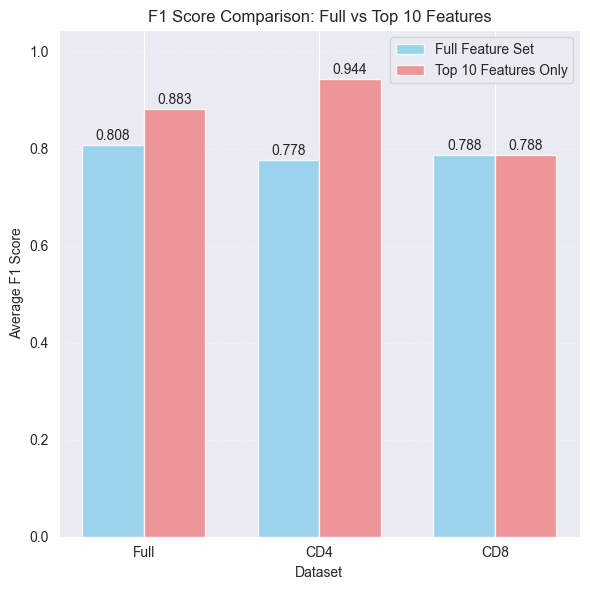

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure
plt.figure(figsize=(6, 6))
bar_width = 0.35
opacity = 0.8

# Datasets and their scores
datasets = {
    'Full': (np.mean(rf_scores), np.mean(rf_filtered_scores)),
    'CD4': (np.mean(cd4_rf_scores), np.mean(cd4_rf_filtered_scores)),
    'CD8': (np.mean(cd8_rf_scores), np.mean(cd8_rf_filtered_scores))
}

# Prepare data for plotting
dataset_names = list(datasets.keys())
full_scores = [scores[0] for scores in datasets.values()]
truncated_scores = [scores[1] for scores in datasets.values()]

# Set positions for the bars
index = np.arange(len(datasets))

# Plot the bars
plt.bar(index - bar_width/2, full_scores, bar_width,
        alpha=opacity, color='skyblue', label='Full Feature Set')
plt.bar(index + bar_width/2, truncated_scores, bar_width,
        alpha=opacity, color='lightcoral', label=f'Top {TOP_FEATURES} Features Only')

# Add data labels on the bars
for i, v in enumerate(full_scores):
    plt.text(i - bar_width/2, v + 0.01, f'{v:.3f}', ha='center')

for i, v in enumerate(truncated_scores):
    plt.text(i + bar_width/2, v + 0.01, f'{v:.3f}', ha='center')

# Customize the plot
plt.xlabel('Dataset')
plt.ylabel('Average F1 Score')
plt.title(f'F1 Score Comparison: Full vs Top {TOP_FEATURES} Features')
plt.xticks(index, dataset_names)
plt.ylim(0, max(max(full_scores), max(truncated_scores)) + 0.1)  # Ensure y-axis fits all bars with some padding
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('output/f1_score_comparison.svg', dpi=300)
plt.show()

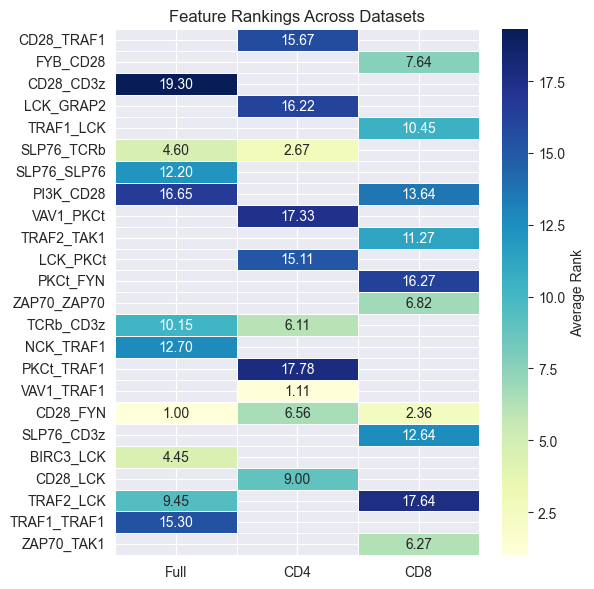

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Number of top features to visualize
n_features = 10

# Prepare data for plotting
datasets = {
    'Full': (rf_rank_avg[:n_features], rf_filtered_rank_avg),
    'CD4': (cd4_rf_rank_avg[:n_features], cd4_rf_filtered_rank_avg),
    'CD8': (cd8_rf_rank_avg[:n_features], cd8_rf_filtered_rank_avg)
}

# Alternative: heatmap visualization
plt.figure(figsize=(6, 6))
# Combine top features from all datasets
all_features = set()
for (full_df, _) in datasets.values():
    for feature in full_df['Feature'][:n_features]:
        all_features.add(feature)

# Create heatmap data
heatmap_data = []
for feature in all_features:
    row = []
    for dataset_name, (full_df, trunc_df) in datasets.items():
        # Get rank for non-truncated
        full_rank = full_df[full_df['Feature'] == feature]
        if not full_rank.empty:
            row.append(full_rank.iloc[0]['Rank'])
        else:
            row.append(np.nan)

    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data,
                          index=list(all_features),
                          columns=[name for name in datasets.keys()])

# Plot heatmap
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt='.2f',
            linewidths=.5, cbar_kws={'label': 'Average Rank'})
plt.title('Feature Rankings Across Datasets')
plt.tight_layout()
plt.savefig('output/feature_rankings_heatmap.svg', dpi=300)
plt.show()

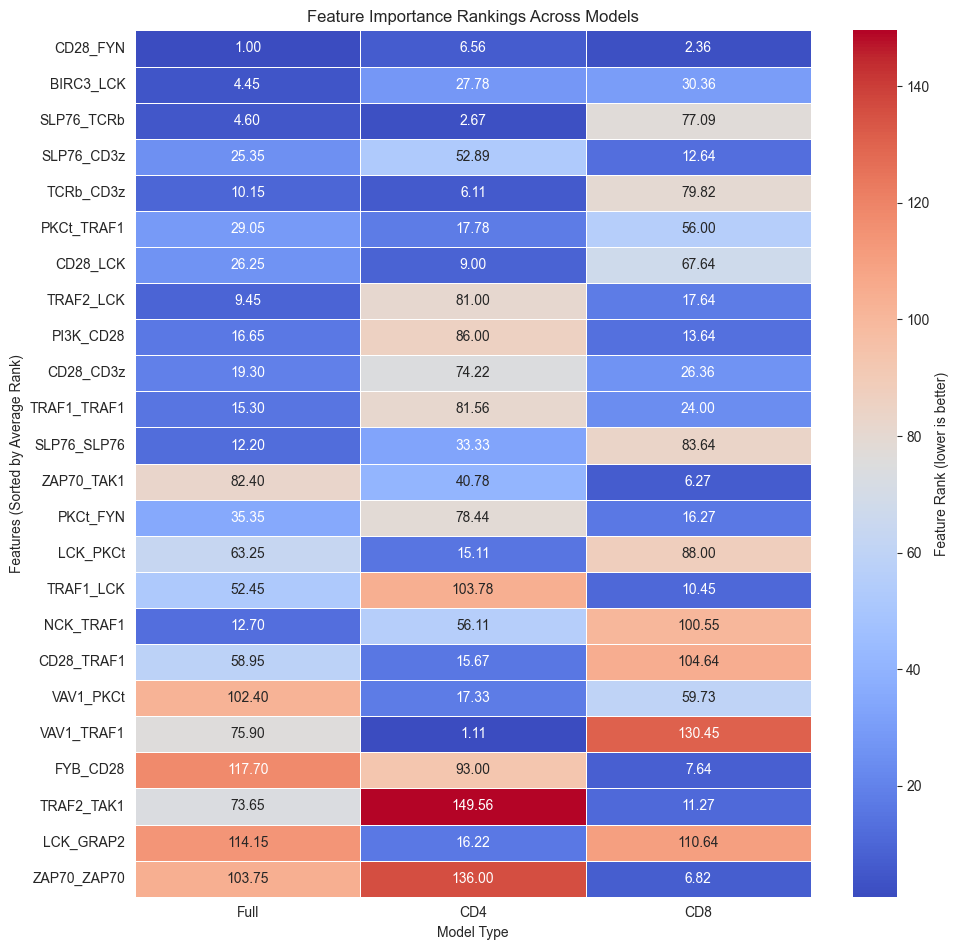

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Number of top features to include from each model
n_top_features = 10

# Get top features from each model
features_full = set(rf_rank_avg['Feature'][:n_top_features])
features_cd4 = set(cd4_rf_rank_avg['Feature'][:n_top_features])
features_cd8 = set(cd8_rf_rank_avg['Feature'][:n_top_features])

# Combine all unique top features
all_top_features = features_full.union(features_cd4).union(features_cd8)

# Create a DataFrame to hold ranks for each feature across models
heatmap_data = []
for feature in all_top_features:
    # Get rank for each model (use NaN if feature not in top N)
    full_rank = rf_rank_avg[rf_rank_avg['Feature'] == feature]['Rank'].values
    full_value = full_rank[0] if len(full_rank) > 0 else np.nan

    cd4_rank = cd4_rf_rank_avg[cd4_rf_rank_avg['Feature'] == feature]['Rank'].values
    cd4_value = cd4_rank[0] if len(cd4_rank) > 0 else np.nan

    cd8_rank = cd8_rf_rank_avg[cd8_rf_rank_avg['Feature'] == feature]['Rank'].values
    cd8_value = cd8_rank[0] if len(cd8_rank) > 0 else np.nan

    # Calculate average rank (ignoring NaN values)
    ranks = [r for r in [full_value, cd4_value, cd8_value] if not np.isnan(r)]
    avg_rank = np.mean(ranks) if ranks else np.nan

    heatmap_data.append({
        'Feature': feature,
        'Full': full_value,
        'CD4': cd4_value,
        'CD8': cd8_value,
        'Average Rank': avg_rank
    })

# Convert to DataFrame and sort by average rank
heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df.sort_values('Average Rank')

# Extract the data for the heatmap
plot_data = heatmap_df.set_index('Feature')[['Full', 'CD4', 'CD8']]

# Create heatmap
plt.figure(figsize=(10, max(8, len(all_top_features)*0.4)))
sns.heatmap(plot_data, annot=True, cmap="coolwarm", fmt='.2f',
            linewidths=.5, cbar_kws={'label': 'Feature Rank (lower is better)'})

plt.title('Feature Importance Rankings Across Models')
plt.xlabel('Model Type')
plt.ylabel('Features (Sorted by Average Rank)')
plt.tight_layout()
plt.savefig('output/feature_importance_heatmap.svg', dpi=300)
plt.show()

In [21]:
# run LDA on the main data
unnorm_df = pd.read_csv('../Step1Normalization/output/normalized_output.csv', index_col=0)
# remove all the columns that are not ppi and not TARGET
unnorm_df = unnorm_df[[col for col in unnorm_df.columns if '_' in col or col == TARGET]]
unnorm_df

,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,BIRC3_ZAP70,FYB_ZAP70,LCK_ZAP70,NCK_ZAP70,PKCt_ZAP70,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,CRS
CAR_19_447,-9.499414,60.643485,16.960218,2.236230,7.205134,16.653537,-40.670511,-2.827491,16.044429,8.064157,...,2.080139,5.474296,-2.493611,-12.055875,5.620332,5.061111,1.132791,-2.879090,-23.100227,1.0
CAR_19_452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
CAR_19_474,5.427434,3.846624,2.925624,-1.888406,4.971299,1.515096,2.974317,0.229601,8.928811,-9.897056,...,8.248643,-11.549542,6.618649,-5.865413,3.490255,5.677711,2.046888,-6.710738,-14.842007,1.0
CAR_19_411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
CAR_N3_874_1,-12.538388,0.991425,-2.647236,4.065031,-4.677405,16.549386,-6.261341,6.418301,-2.487211,3.381040,...,-0.674188,0.688045,-2.650827,4.177128,-9.078157,7.540367,-3.205128,5.497651,143.899517,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OR_US_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
CRS_US_4,1.045306,-2.868925,-1.922169,-0.554275,-1.278044,-6.189761,2.994708,3.733184,2.101398,-44.722020,...,-2.194721,-4.941265,-4.793112,-4.064024,0.318831,-2.971317,-3.215021,5.120820,208.653684,1.0
OR_US_4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
CRS_US_5,6.041236,7.091789,10.061257,-4.016316,6.545511,-2.058339,-6.392292,-0.313622,15.150684,79.957809,...,-1.771871,0.264601,-2.105141,-9.543905,0.945848,3.106612,-0.803358,2.068715,-33.268856,1.0
